Предобработка оригинального изображения...


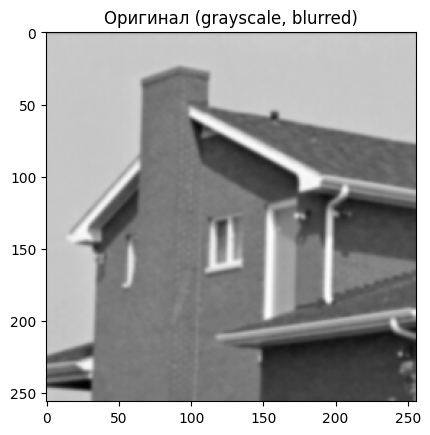

Длина WHT-хэша: 256 (блоков 16×16)
Длина Кравчук-хэша: 64 (блоков 32×32)
Общая длина: 320
Первые 32 бита: [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]

Запуск 1000 итераций наложения шума (sigma=200)...
  Выполнено 100 итераций
  Выполнено 200 итераций
  Выполнено 300 итераций
  Выполнено 400 итераций
  Выполнено 500 итераций
  Выполнено 600 итераций
  Выполнено 700 итераций
  Выполнено 800 итераций
  Выполнено 900 итераций
  Выполнено 1000 итераций

Тестирование завершено за 13.93 сек.

РЕЗУЛЬТАТЫ ПОСЛЕ 1000 ИТЕРАЦИЙ

WHT-хэш (длина 256):
  Среднее число несовпадающих бит: 49.54
  Средний NHD: 0.1935

Кравчук-хэш (длина 64):
  Среднее число несовпадающих бит: 3.08
  Средний NHD: 0.0482

Общий хэш (длина 320):
  Среднее число несовпадающих бит: 52.62
  Средний NHD: 0.1644


In [13]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy.linalg import hadamard
import time
import math

# Вспомогательные функции

def preprocess(img_color, target_size=(256, 256)):
    gray = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)
    resized = cv2.resize(gray, target_size, interpolation=cv2.INTER_AREA)
    blurred = cv2.GaussianBlur(resized, (5, 5), 1.0)
    return blurred.astype(np.float32)


def split_blocks(img, block_size):
    h, w = img.shape
    assert h % block_size == 0 and w % block_size == 0
    blocks_h = h // block_size
    blocks_w = w // block_size
    blocks = img.reshape(blocks_h, block_size, blocks_w, block_size)
    blocks = blocks.swapaxes(1, 2).reshape(-1, block_size, block_size)
    return blocks


def get_zigzag_indices(n):
    indices = []
    for s in range(2 * n - 1):
        if s % 2 == 0:
            for i in range(min(s, n-1), max(-1, s-n), -1):
                j = s-i
                indices.append((i, j))
        else:
            for j in range(min(s, n-1), max(-1, s-n), -1):
                i = s-j
                indices.append((i, j))
    return indices


def wht2d(block, H):
    return H @ block @ H.T


def extract_wht_features(blocks, num_coeffs):
    n = blocks.shape[1]
    H = hadamard(n, dtype=np.float32) / np.sqrt(n)
    zigzag = get_zigzag_indices(n)
    n_blocks = blocks.shape[0]
    features = np.zeros((num_coeffs, n_blocks), dtype=np.float32)
    for i in range(n_blocks):
        coeff = wht2d(blocks[i], H)
        for k, (r, c) in enumerate(zigzag[:num_coeffs]):
            features[k, i] = coeff[r, c]
    return features


def krawtchouk_poly_recurrence(n, x, p, N):
    if n == 0:
        return 1.0
    if n == 1:
        return 1.0 - x / (p * (N - 1))

    K_prev = 1.0
    K_curr = 1.0 - x / (p * (N - 1))
    for m in range(1, n):
        A = (m + x * (1 - 2 * p) - p * (N - 1)) / (m + 1)
        B = -p * (1 - p) * ((N - 1) - m) / (m + 1)
        K_next = A * K_curr + B * K_prev
        K_prev, K_curr = K_curr, K_next
    return K_curr


def weighted_krawtchouk_matrix(N, p=0.5, order=3):
    w = np.array([math.comb(N - 1, x) * (p ** x) * ((1 - p) ** (N - 1 - x)) for x in range(N)])

    K = np.zeros((order + 1, N))
    for n in range(order + 1):
        for x in range(N):
            K[n, x] = krawtchouk_poly_recurrence(n, x, p, N)

    rho = np.array([abs(math.comb(N - 1, n) * (p / (1 - p)) ** n) for n in range(order + 1)])
    
    K_bar = np.zeros_like(K)
    for n in range(order + 1):
        for x in range(N):
            K_bar[n, x] = K[n, x] * np.sqrt(w[x] / rho[n])
    return K_bar


def build_krawtchouk_bases(block_size, p1=0.5, p2=0.5, order=3):
    Kx = weighted_krawtchouk_matrix(block_size, p1, order)
    Ky = weighted_krawtchouk_matrix(block_size, p2, order)

    bases = []
    for n in range(order + 1):
        for m in range(order + 1):
            bases.append(np.outer(Kx[n], Ky[m]))
    return bases


def extract_krawtchouk_features(blocks, bases):
    n_blocks = blocks.shape[0]
    n_mom = len(bases)
    features = np.zeros((n_mom, n_blocks), dtype=np.float32)
    for i in range(n_blocks):
        for j, basis in enumerate(bases):
            features[j, i] = np.sum(blocks[i] * basis)
    return features


def hash_from_features(features):
    global_mean = np.mean(features)
    col_means = np.mean(features, axis=0)
    return (col_means >= global_mean).astype(np.uint8)

# Основная часть

if __name__ == "__main__":
    image_path = 'house.tiff'
    target_size = (256, 256)
    wht_block_size = 16
    kraw_block_size = 32
    num_coeffs = 128
    sigma = 200
    num_iterations = 1000
    order = 3
    p1 = p2 = 0.5

    original = cv2.imread(image_path)
    if original is None:
        raise FileNotFoundError(f"Не удалось загрузить {image_path}")

    print("Предобработка оригинального изображения...")
    proc_orig = preprocess(original, target_size)

    plt.imshow(proc_orig, cmap='gray')
    plt.title('Оригинал (grayscale, blurred)')
    plt.show()

    blocks_wht = split_blocks(proc_orig, wht_block_size)
    blocks_kraw = split_blocks(proc_orig, kraw_block_size)

    # WHT
    wht_features = extract_wht_features(blocks_wht, num_coeffs)
    hash_wht = hash_from_features(wht_features)

    # Кравчук
    kraw_bases = build_krawtchouk_bases(kraw_block_size, p1, p2, order)
    kraw_features = extract_krawtchouk_features(blocks_kraw, kraw_bases)
    hash_kraw = hash_from_features(kraw_features)

    full_hash = np.concatenate((hash_wht, hash_kraw))

    print(f"Длина WHT-хэша: {len(hash_wht)} (блоков {wht_block_size}×{wht_block_size})")
    print(f"Длина Кравчук-хэша: {len(hash_kraw)} (блоков {kraw_block_size}×{kraw_block_size})")
    print(f"Общая длина: {len(full_hash)}")

    # Тест на устойчивость к шуму
    total_wht_diff = 0
    total_wht_nhd = 0.0
    total_kraw_diff = 0
    total_kraw_nhd = 0.0
    total_full_diff = 0
    total_full_nhd = 0.0

    print(f"\nЗапуск {num_iterations} итераций наложения шума (sigma={sigma})...")
    start = time.perf_counter()

    for i in range(num_iterations):
        noise = np.random.normal(0, sigma, original.shape).astype(np.float32)
        noisy_color = original.astype(np.float32) + noise
        noisy_color = np.clip(noisy_color, 0, 255).astype(np.uint8)

        proc_noisy = preprocess(noisy_color, target_size)

        blocks_wht_noisy = split_blocks(proc_noisy, wht_block_size)
        blocks_kraw_noisy = split_blocks(proc_noisy, kraw_block_size)

        # Хэши для зашумлённого
        wht_n = extract_wht_features(blocks_wht_noisy, num_coeffs)
        hash_wht_n = hash_from_features(wht_n)

        kraw_n = extract_krawtchouk_features(blocks_kraw_noisy, kraw_bases)
        hash_kraw_n = hash_from_features(kraw_n)

        full_n = np.concatenate((hash_wht_n, hash_kraw_n))

        # Сравнение
        total_wht_diff += np.sum(hash_wht != hash_wht_n)
        total_wht_nhd += np.sum(hash_wht != hash_wht_n) / len(hash_wht)

        total_kraw_diff += np.sum(hash_kraw != hash_kraw_n)
        total_kraw_nhd += np.sum(hash_kraw != hash_kraw_n) / len(hash_kraw)

        total_full_diff += np.sum(full_hash != full_n)
        total_full_nhd += np.sum(full_hash != full_n) / len(full_hash)

        if (i + 1) % 100 == 0:
            print(f"  Выполнено {i + 1} итераций")

    elapsed = time.perf_counter() - start
    print(f"\nТест завершен за {elapsed:.2f} сек.\n")

    print("=" * 60)
    print(f"РЕЗУЛЬТАТЫ ПОСЛЕ {num_iterations} ИТЕРАЦИЙ")
    print("=" * 60)

    avg_wht_diff = total_wht_diff / num_iterations
    avg_wht_nhd = total_wht_nhd / num_iterations
    print(f"\nWHT-хэш (длина {len(hash_wht)}):")
    print(f"  Среднее число несовпадающих бит: {avg_wht_diff:.2f}")
    print(f"  Средний NHD: {avg_wht_nhd:.4f}")

    avg_kraw_diff = total_kraw_diff / num_iterations
    avg_kraw_nhd = total_kraw_nhd / num_iterations
    print(f"\nКравчук-хэш (длина {len(hash_kraw)}):")
    print(f"  Среднее число несовпадающих бит: {avg_kraw_diff:.2f}")
    print(f"  Средний NHD: {avg_kraw_nhd:.4f}")

    avg_full_diff = total_full_diff / num_iterations
    avg_full_nhd = total_full_nhd / num_iterations
    print(f"\nОбщий хэш (длина {len(full_hash)}):")
    print(f"  Среднее число несовпадающих бит: {avg_full_diff:.2f}")
    print(f"  Средний NHD: {avg_full_nhd:.4f}")

WHT-хэш: 256 бит (блоки 16×16)
Krawtchouk-хэш: 64 бит (блоки 32×32)
Общий хэш: 320 бит


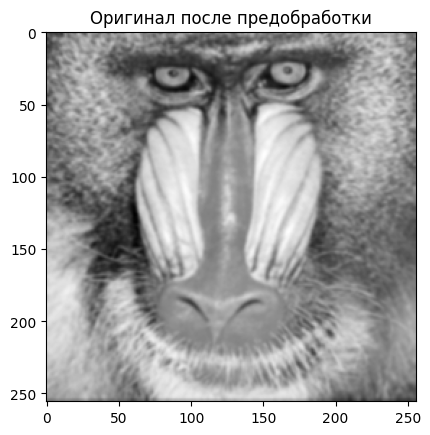


Тестирование: 1000 итераций, шум соль-и-перец (prob=0.5)...
  Выполнено 100 итераций
  Выполнено 200 итераций
  Выполнено 300 итераций
  Выполнено 400 итераций
  Выполнено 500 итераций
  Выполнено 600 итераций
  Выполнено 700 итераций
  Выполнено 800 итераций
  Выполнено 900 итераций
  Выполнено 1000 итераций

Тестирование завершено за 14.37 сек.

СРЕДНИЕ NHD ПОСЛЕ 1000 ИТЕРАЦИЙ
WHT-хэш (256 бит) : 0.1906
Krawtchouk-хэш (64 бит): 0.0874
Общий хэш (320 бит) : 0.1700


In [44]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy.linalg import hadamard
import time
import math
import os

# Вспомогательные функции

def preprocess(img_color, target_size=(256, 256)):
    gray = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)
    resized = cv2.resize(gray, target_size, interpolation=cv2.INTER_AREA)
    blurred = cv2.GaussianBlur(resized, (5, 5), 1.0)
    return blurred.astype(np.float32)

def split_blocks(img, block_size):
    h, w = img.shape
    assert h % block_size == 0 and w % block_size == 0
    blocks_h = h // block_size
    blocks_w = w // block_size
    blocks = img.reshape(blocks_h, block_size, blocks_w, block_size)
    blocks = blocks.swapaxes(1, 2).reshape(-1, block_size, block_size)
    return blocks

def get_zigzag_indices(n):
    indices = []
    for s in range(2*n-1):
        if s % 2 == 0:
            for i in range(min(s, n-1), max(-1, s-n), -1):
                j = s-i
                indices.append((i, j))
        else:
            for j in range(min(s, n-1), max(-1, s-n), -1):
                i = s - j
                indices.append((i, j))
    return indices

def hadamard_matrix(n):
    H = hadamard(n, dtype=np.float32)
    return H / np.sqrt(n)

def wht2d(block, H):
    return H @ block @ H.T

def extract_wht(blocks, num_coeffs):
    n = blocks.shape[1]
    H = hadamard_matrix(n)
    zigzag = get_zigzag_indices(n)
    n_blocks = blocks.shape[0]
    features = np.zeros((num_coeffs, n_blocks), dtype=np.float32)
    for i in range(n_blocks):
        coeff = wht2d(blocks[i], H)
        for k, (r, c) in enumerate(zigzag[:num_coeffs]):
            features[k, i] = coeff[r, c]
    return features

def generate_hash(features):
    global_mean = np.mean(features)
    col_means = np.mean(features, axis=0)
    return (col_means >= global_mean).astype(np.uint8)
    
#  Моменты Кравчука

def krawtchouk_poly_recurrence(n, x, p, N):
    if n == 0:
        return 1.0
    if n == 1:
        return 1.0 - x / (p * (N - 1))

    K_prev = 1.0
    K_curr = 1.0 - x / (p * (N - 1))
    for m in range(1, n):
        A = (m + x * (1 - 2 * p) - p * (N - 1)) / (m + 1)
        B = -p * (1 - p) * ((N - 1) - m) / (m + 1)
        K_next = A * K_curr + B * K_prev
        K_prev, K_curr = K_curr, K_next
    return K_curr

def weighted_krawtchouk_matrix(N, p=0.5, order=3):"
    if not (0 < p < 1):
        raise ValueError("p должно быть в интервале (0,1)")

    w = np.array([math.comb(N - 1, x) * (p ** x) * ((1 - p) ** (N - 1 - x)) for x in range(N)])

    K = np.zeros((order + 1, N))
    for n in range(order + 1):
        for x in range(N):
            K[n, x] = krawtchouk_poly_recurrence(n, x, p, N)

    rho = np.array([abs(math.comb(N - 1, n) * (p / (1 - p)) ** n) for n in range(order + 1)])

    K_bar = np.zeros_like(K)
    for n in range(order + 1):
        for x in range(N):
            K_bar[n, x] = K[n, x] * np.sqrt(w[x] / rho[n])
    return K_bar


def krawtchouk_bases(block_size, p1=0.5, p2=0.5, order=3):
    Kx = weighted_krawtchouk_matrix(block_size, p1, order)
    Ky = weighted_krawtchouk_matrix(block_size, p2, order)
    bases = []
    for n in range(order + 1):
        for m in range(order + 1):
            bases.append(np.outer(Kx[n], Ky[m]))
    return bases


def extract_krawtchouk(blocks, bases):
    n_blocks = blocks.shape[0]
    n_mom = len(bases)
    features = np.zeros((n_mom, n_blocks), dtype=np.float32)
    for i in range(n_blocks):
        for j, basis in enumerate(bases):
            features[j, i] = np.sum(blocks[i] * basis)
    return features

# Добавление шума

def add_salt_pepper(img, prob=0.05):
    noisy = img.copy()
    h, w = img.shape[:2]
    mask = np.random.random((h, w))
    noisy[mask < prob / 2] = [255, 255, 255]
    noisy[(mask >= prob / 2) & (mask < prob)] = [0, 0, 0]
    return noisy

# Основная часть

def compute_hashes(img, target_size, wht_block_size, kraw_block_size, num_coeffs, kraw_bases):
    gray = preprocess(img, target_size)

    blocks_wht = split_blocks(gray, wht_block_size)
    wht_feat = extract_wht(blocks_wht, num_coeffs)
    hash_wht = generate_hash(wht_feat)

    blocks_kraw = split_blocks(gray, kraw_block_size)
    kraw_feat = extract_krawtchouk(blocks_kraw, kraw_bases)
    hash_kraw = generate_hash(kraw_feat)

    full_hash = np.concatenate((hash_wht, hash_kraw))
    return hash_wht, hash_kraw, full_hash


if __name__ == "__main__":
    image_path = 'mandrill.tiff'
    target_size = (256, 256)
    wht_block_size = 16
    kraw_block_size = 32
    num_coeffs = 128
    prob_noise = 0.5
    num_iterations = 1000
    order = 3
    p1 = p2 = 0.5

    if not os.path.exists(image_path):
        raise FileNotFoundError(f"Файл {image_path} не найден")

    orig_color = cv2.imread(image_path)

    kraw_bases = krawtchouk_bases(kraw_block_size, p1, p2, order)

    hash_wht_orig, hash_kraw_orig, full_hash_orig = compute_hashes(
        orig_color, target_size, wht_block_size, kraw_block_size, num_coeffs, kraw_bases
    )

    print(f"WHT-хэш: {len(hash_wht_orig)} бит (блоки {wht_block_size}×{wht_block_size})")
    print(f"Krawtchouk-хэш: {len(hash_kraw_orig)} бит (блоки {kraw_block_size}×{kraw_block_size})")
    print(f"Общий хэш: {len(full_hash_orig)} бит")

    gray_orig = preprocess(orig_color, target_size)
    plt.imshow(gray_orig, cmap='gray')
    plt.title("Оригинал после предобработки")
    plt.show()

    # Тест на устойчивость к шуму
    total_nhd_wht = 0.0
    total_nhd_kraw = 0.0
    total_nhd_full = 0.0

    print(f"\nТест: {num_iterations} итераций, шум соль и перец (prob={prob_noise})...")
    start = time.perf_counter()

    for i in range(num_iterations):
        noisy = add_salt_pepper(orig_color, prob_noise)
        hash_wht_n, hash_kraw_n, full_hash_n = compute_hashes(
            noisy, target_size, wht_block_size, kraw_block_size, num_coeffs, kraw_bases
        )

        total_nhd_wht += np.sum(hash_wht_orig != hash_wht_n) / len(hash_wht_orig)
        total_nhd_kraw += np.sum(hash_kraw_orig != hash_kraw_n) / len(hash_kraw_orig)
        total_nhd_full += np.sum(full_hash_orig != full_hash_n) / len(full_hash_orig)

        if (i + 1) % 100 == 0:
            print(f"  Выполнено {i + 1} итераций")

    elapsed = time.perf_counter() - start
    print(f"\nТест завершен за {elapsed:.2f} сек.")

    avg_wht = total_nhd_wht / num_iterations
    avg_kraw = total_nhd_kraw / num_iterations
    avg_full = total_nhd_full / num_iterations

    print("\n" + "=" * 60)
    print(f"СРЕДНИЕ NHD ПОСЛЕ {num_iterations} ИТЕРАЦИЙ")
    print("=" * 60)
    print(f"WHT-хэш ({len(hash_wht_orig)} бит) : {avg_wht:.4f}")
    print(f"Krawtchouk-хэш ({len(hash_kraw_orig)} бит): {avg_kraw:.4f}")
    print(f"Общий хэш ({len(full_hash_orig)} бит) : {avg_full:.4f}")

WHT-хэш: 256 бит (блоки 16×16)
Krawtchouk-хэш: 64 бит (блоки 32×32)
Общий хэш: 320 бит

JPEG сжатие (качество 50)...


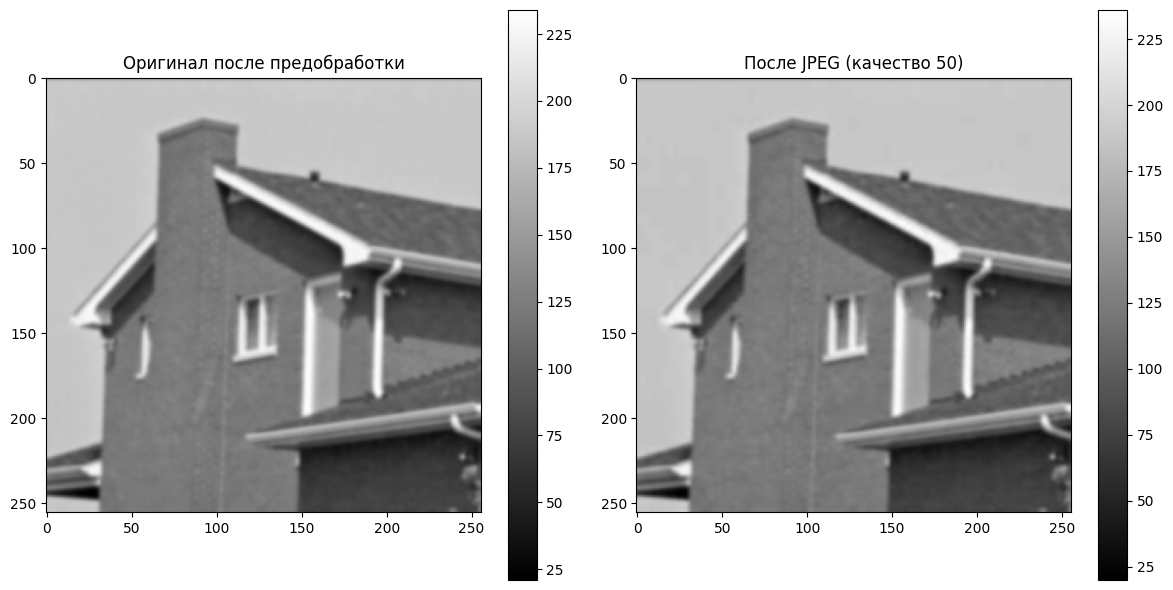


СРАВНЕНИЕ ИСХОДНОГО И СЖАТОГО ИЗОБРАЖЕНИЙ

WHT-хэш (256 бит): NHD = 0.0117
Krawtchouk-хэш (64 бит): NHD = 0.0000
Общий хэш (320 бит): NHD = 0.0094


In [59]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy.linalg import hadamard
import math
import os

# Вспомогательные функции

def preprocess(img_color, target_size=(256, 256)):
    gray = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)
    resized = cv2.resize(gray, target_size, interpolation=cv2.INTER_AREA)
    blurred = cv2.GaussianBlur(resized, (5, 5), 1.0)
    return blurred.astype(np.float32)

def split_blocks(img, block_size):
    h, w = img.shape
    assert h % block_size == 0 and w % block_size == 0
    blocks_h = h // block_size
    blocks_w = w // block_size
    blocks = img.reshape(blocks_h, block_size, blocks_w, block_size)
    blocks = blocks.swapaxes(1, 2).reshape(-1, block_size, block_size)
    return blocks
    
def get_zigzag_indices(n):
    indices = []
    for s in range(2 * n - 1):
        if s % 2 == 0:
            for i in range(min(s, n-1), max(-1, s-n), -1):
                j = s-i
                indices.append((i, j))
        else:
            for j in range(min(s, n-1), max(-1, s-n), -1):
                i = s-j
                indices.append((i, j))
    return indices

def hadamard_norm(n):
    H = hadamard(n, dtype=np.float32)
    return H / np.sqrt(n)

def wht2d(block, H):
    return H @ block @ H.T

def extract_wht(blocks, num_coeffs):
    n = blocks.shape[1]
    H = hadamard_norm(n)
    zigzag = get_zigzag_indices(n)
    n_blocks = blocks.shape[0]
    features = np.zeros((num_coeffs, n_blocks), dtype=np.float32)
    for i in range(n_blocks):
        coeff = wht2d(blocks[i], H)
        for k, (r, c) in enumerate(zigzag[:num_coeffs]):
            features[k, i] = coeff[r, c]
    return features

def hash_from_features(features):
    global_mean = np.mean(features)
    col_means = np.mean(features, axis=0)
    return (col_means >= global_mean).astype(np.uint8)

def krawtchouk_poly_recurrence(n, x, p, N):
    if n == 0:
        return 1.0
    if n == 1:
        return 1.0 - x / (p * (N - 1))

    K_prev = 1.0
    K_curr = 1.0 - x / (p * (N - 1))
    for m in range(1, n):
        A = (m + x * (1 - 2 * p) - p * (N - 1)) / (m + 1)
        B = -p * (1 - p) * ((N - 1) - m) / (m + 1)
        K_next = A * K_curr + B * K_prev
        K_prev, K_curr = K_curr, K_next
    return K_curr


def weighted_krawtchouk_matrix(N, p=0.5, order=3):
    if not (0 < p < 1):
        raise ValueError("p должно быть в интервале (0,1)")

    w = np.array([math.comb(N - 1, x) * (p ** x) * ((1 - p) ** (N - 1 - x)) for x in range(N)])

    K = np.zeros((order + 1, N))
    for n in range(order + 1):
        for x in range(N):
            K[n, x] = krawtchouk_poly_recurrence(n, x, p, N)

    rho = np.array([abs(math.comb(N - 1, n) * (p / (1 - p)) ** n) for n in range(order + 1)])

    K_bar = np.zeros_like(K)
    for n in range(order + 1):
        for x in range(N):
            K_bar[n, x] = K[n, x] * np.sqrt(w[x] / rho[n])
    return K_bar

def krawtchouk_bases(block_size, p1=0.5, p2=0.5, order=3):
    Kx = weighted_krawtchouk_matrix(block_size, p1, order)
    Ky = weighted_krawtchouk_matrix(block_size, p2, order)
    bases = []
    for n in range(order + 1):
        for m in range(order + 1):
            bases.append(np.outer(Kx[n], Ky[m]))
    return bases

def extract_krawtchouk(blocks, bases):
    n_blocks = blocks.shape[0]
    n_mom = len(bases)
    features = np.zeros((n_mom, n_blocks), dtype=np.float32)
    for i in range(n_blocks):
        for j, basis in enumerate(bases):
            features[j, i] = np.sum(blocks[i] * basis)
    return features

# Добавление JPEG-сжатия

def jpeg_compress(img, quality=50):

    encode_param = [cv2.IMWRITE_JPEG_QUALITY, quality]
    success, encoded = cv2.imencode('.jpg', img, encode_param)
    if not success:
        raise ValueError("JPEG encoding failed")
    return cv2.imdecode(encoded, cv2.IMREAD_COLOR)

# Основная часть

def compute_hashes(img, target_size, wht_block_size, kraw_block_size, num_coeffs, kraw_bases):
    gray = preprocess(img, target_size)

    blocks_wht = split_blocks(gray, wht_block_size)
    wht_feat = extract_wht(blocks_wht, num_coeffs)
    hash_wht = hash_from_features(wht_feat)

    blocks_kraw = split_blocks(gray, kraw_block_size)
    kraw_feat = extract_krawtchouk(blocks_kraw, kraw_bases)
    hash_kraw = hash_from_features(kraw_feat)

    full_hash = np.concatenate((hash_wht, hash_kraw))
    return hash_wht, hash_kraw, full_hash


if __name__ == "__main__":
    image_path = 'house.tiff'
    target_size = (256, 256)
    wht_block_size = 16
    kraw_block_size = 32
    num_coeffs = 128
    jpeg_quality = 50
    order = 3
    p1 = p2 = 0.5

    if not os.path.exists(image_path):
        raise FileNotFoundError(f"Файл {image_path} не найден")

    orig_color = cv2.imread(image_path)

    kraw_bases = krawtchouk_bases(kraw_block_size, p1, p2, order)

    hash_wht_orig, hash_kraw_orig, full_hash_orig = compute_hashes(
        orig_color, target_size, wht_block_size, kraw_block_size, num_coeffs, kraw_bases
    )

    print(f"WHT-хэш: {len(hash_wht_orig)} бит (блоки {wht_block_size}×{wht_block_size})")
    print(f"Krawtchouk-хэш: {len(hash_kraw_orig)} бит (блоки {kraw_block_size}×{kraw_block_size})")
    print(f"Общий хэш: {len(full_hash_orig)} бит")

    gray_orig = preprocess(orig_color, target_size)
    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.imshow(gray_orig, cmap='gray')
    plt.title('Оригинал после предобработки')
    plt.colorbar()

    # JPEG-сжатие
    print(f"\nJPEG сжатие (качество {jpeg_quality})...")
    compressed = jpeg_compress(orig_color, jpeg_quality)

    # Хэши сжатого
    hash_wht_comp, hash_kraw_comp, full_hash_comp = compute_hashes(
        compressed, target_size, wht_block_size, kraw_block_size, num_coeffs, kraw_bases
    )
    
    gray_comp = preprocess(compressed, target_size)
    plt.subplot(1, 2, 2)
    plt.imshow(gray_comp, cmap='gray')
    plt.title(f'После JPEG (качество {jpeg_quality})')
    plt.colorbar()
    plt.tight_layout()
    plt.show()

    # Сравнение
    nhd_wht = np.sum(hash_wht_orig != hash_wht_comp) / len(hash_wht_orig)
    nhd_kraw = np.sum(hash_kraw_orig != hash_kraw_comp) / len(hash_kraw_orig)
    nhd_full = np.sum(full_hash_orig != full_hash_comp) / len(full_hash_orig)

    print("\n" + "=" * 60)
    print("СРАВНЕНИЕ ИСХОДНОГО И СЖАТОГО ИЗОБРАЖЕНИЙ")
    print("=" * 60)
    print(f"\nWHT-хэш ({len(hash_wht_orig)} бит): NHD = {nhd_wht:.4f}")
    print(f"Krawtchouk-хэш ({len(hash_kraw_orig)} бит): NHD = {nhd_kraw:.4f}")
    print(f"Общий хэш ({len(full_hash_orig)} бит): NHD = {nhd_full:.4f}")

Предобработка оригинального изображения...


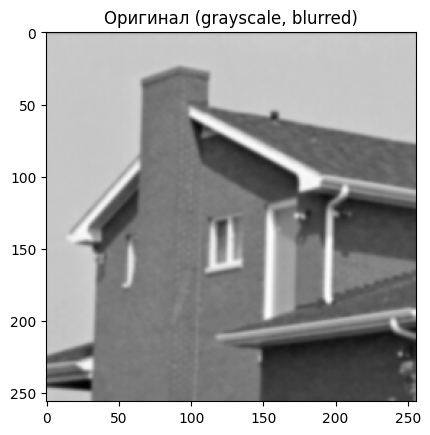

Длина WHT-хэша: 256 (блоков 16×16)
Длина Кравчук-хэша: 64 (блоков 32×32)
Общая длина: 320
Первые 32 бита: [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]

Применение гамма-коррекции с gamma=6.0...

РЕЗУЛЬТАТЫ СРАВНЕНИЯ ПОСЛЕ ГАММА-КОРРЕКЦИИ

WHT-хэш (длина 256):
  Несовпадающих бит: 11
  NHD: 0.0430

Кравчук-хэш (длина 64):
  Несовпадающих бит: 3
  NHD: 0.0469

Общий хэш (длина 320):
  Несовпадающих бит: 14
  NHD: 0.0437


In [68]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy.linalg import hadamard
import time
import math

# Вспомогательные функции

def preprocess(img_color, target_size=(256, 256)):
    gray = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)
    resized = cv2.resize(gray, target_size, interpolation=cv2.INTER_AREA)
    blurred = cv2.GaussianBlur(resized, (5, 5), 1.0)
    return blurred.astype(np.float32)

def split_blocks(img, block_size):
    h, w = img.shape
    assert h % block_size == 0 and w % block_size == 0
    blocks_h = h // block_size
    blocks_w = w // block_size
    blocks = img.reshape(blocks_h, block_size, blocks_w, block_size)
    blocks = blocks.swapaxes(1, 2).reshape(-1, block_size, block_size)
    return blocks


def get_zigzag_indices(n):
    indices = []
    for s in range(2*n-1):
        if s % 2 == 0:
            for i in range(min(s, n-1), max(-1, s-n), -1):
                j = s-i
                indices.append((i, j))
        else:
            for j in range(min(s, n-1), max(-1, s-n), -1):
                i = s-j
                indices.append((i, j))
    return indices

def wht2d(block, H):
    return H @ block @ H.T

def extract_wht_features(blocks, num_coeffs):
    n = blocks.shape[1]
    H = hadamard(n, dtype=np.float32) / np.sqrt(n)
    zigzag = get_zigzag_indices(n)
    n_blocks = blocks.shape[0]
    features = np.zeros((num_coeffs, n_blocks), dtype=np.float32)
    for i in range(n_blocks):
        coeff = wht2d(blocks[i], H)
        for k, (r, c) in enumerate(zigzag[:num_coeffs]):
            features[k, i] = coeff[r, c]
    return features

def krawtchouk_poly_recurrence(n, x, p, N):
    if n == 0:
        return 1.0
    if n == 1:
        return 1.0 - x / (p * (N - 1))

    K_prev = 1.0
    K_curr = 1.0 - x / (p * (N - 1))
    for m in range(1, n):
        A = (m + x * (1 - 2 * p) - p * (N - 1)) / (m + 1)
        B = -p * (1 - p) * ((N - 1) - m) / (m + 1)
        K_next = A * K_curr + B * K_prev
        K_prev, K_curr = K_curr, K_next
    return K_curr


def weighted_krawtchouk_matrix(N, p=0.5, order=3):
    w = np.array([math.comb(N - 1, x) * (p ** x) * ((1 - p) ** (N - 1 - x)) for x in range(N)])

    K = np.zeros((order + 1, N))
    for n in range(order + 1):
        for x in range(N):
            K[n, x] = krawtchouk_poly_recurrence(n, x, p, N)

    rho = np.array([abs(math.comb(N - 1, n) * (p / (1 - p)) ** n) for n in range(order + 1)])

    K_bar = np.zeros_like(K)
    for n in range(order + 1):
        for x in range(N):
            K_bar[n, x] = K[n, x] * np.sqrt(w[x] / rho[n])
    return K_bar


def build_krawtchouk_bases(block_size, p1=0.5, p2=0.5, order=3):
    Kx = weighted_krawtchouk_matrix(block_size, p1, order)
    Ky = weighted_krawtchouk_matrix(block_size, p2, order)

    bases = []
    for n in range(order + 1):
        for m in range(order + 1):
            bases.append(np.outer(Kx[n], Ky[m]))
    return bases


def extract_krawtchouk_features(blocks, bases):
    n_blocks = blocks.shape[0]
    n_mom = len(bases)
    features = np.zeros((n_mom, n_blocks), dtype=np.float32)
    for i in range(n_blocks):
        for j, basis in enumerate(bases):
            features[j, i] = np.sum(blocks[i] * basis)
    return features

def hash_from_features(features):
    global_mean = np.mean(features)
    col_means = np.mean(features, axis=0)
    return (col_means >= global_mean).astype(np.uint8)

# Добавление гамма-коррекции

def gamma_correction(img, gamma=1.0):
    img_float = img.astype(np.float32) / 255.0
    corrected = np.power(img_float, gamma)
    corrected = np.clip(corrected * 255, 0, 255).astype(np.uint8)
    return corrected

# Основная часть

if __name__ == "__main__":
    # Параметры
    image_path = 'house.tiff'
    target_size = (256, 256)
    wht_block_size = 16
    kraw_block_size = 32
    num_coeffs = 128
    order = 3
    p1 = p2 = 0.5
    gamma_value = 6.0

    original = cv2.imread(image_path)
    if original is None:
        raise FileNotFoundError(f"Не удалось загрузить {image_path}")

    print("Предобработка оригинального изображения...")
    proc_orig = preprocess(original, target_size)

    plt.imshow(proc_orig, cmap='gray')
    plt.title('Оригинал (grayscale, blurred)')
    plt.show()

    blocks_wht = split_blocks(proc_orig, wht_block_size)
    blocks_kraw = split_blocks(proc_orig, kraw_block_size)

    wht_features = extract_wht_features(blocks_wht, num_coeffs)
    hash_wht = hash_from_features(wht_features)

    kraw_bases = build_krawtchouk_bases(kraw_block_size, p1, p2, order)
    kraw_features = extract_krawtchouk_features(blocks_kraw, kraw_bases)
    hash_kraw = hash_from_features(kraw_features)

    full_hash = np.concatenate((hash_wht, hash_kraw))

    print(f"Длина WHT-хэша: {len(hash_wht)} (блоков {wht_block_size}×{wht_block_size})")
    print(f"Длина Кравчук-хэша: {len(hash_kraw)} (блоков {kraw_block_size}×{kraw_block_size})")
    print(f"Общая длина: {len(full_hash)}")

    print(f"\nПрименение гамма-коррекции с gamma={gamma_value}...")
    gamma_img = gamma_correction(original, gamma_value)

    proc_gamma = preprocess(gamma_img, target_size)

    blocks_wht_gamma = split_blocks(proc_gamma, wht_block_size)
    blocks_kraw_gamma = split_blocks(proc_gamma, kraw_block_size)

    # Хэши для искажённого
    wht_features_gamma = extract_wht_features(blocks_wht_gamma, num_coeffs)
    hash_wht_gamma = hash_from_features(wht_features_gamma)

    kraw_features_gamma = extract_krawtchouk_features(blocks_kraw_gamma, kraw_bases)
    hash_kraw_gamma = hash_from_features(kraw_features_gamma)

    full_hash_gamma = np.concatenate((hash_wht_gamma, hash_kraw_gamma))

    # Сравнение
    print("\n" + "=" * 60)
    print("РЕЗУЛЬТАТЫ СРАВНЕНИЯ ПОСЛЕ ГАММА-КОРРЕКЦИИ")
    print("=" * 60)

    wht_diff = np.sum(hash_wht != hash_wht_gamma)
    wht_nhd = wht_diff / len(hash_wht)

    kraw_diff = np.sum(hash_kraw != hash_kraw_gamma)
    kraw_nhd = kraw_diff / len(hash_kraw)

    full_diff = np.sum(full_hash != full_hash_gamma)
    full_nhd = full_diff / len(full_hash)

    print(f"\nWHT-хэш (длина {len(hash_wht)}):")
    print(f"  Несовпадающих бит: {wht_diff}")
    print(f"  NHD: {wht_nhd:.4f}")

    print(f"\nКравчук-хэш (длина {len(hash_kraw)}):")
    print(f"  Несовпадающих бит: {kraw_diff}")
    print(f"  NHD: {kraw_nhd:.4f}")

    print(f"\nОбщий хэш (длина {len(full_hash)}):")
    print(f"  Несовпадающих бит: {full_diff}")
    print(f"  NHD: {full_nhd:.4f}")

Предобработка оригинального изображения...


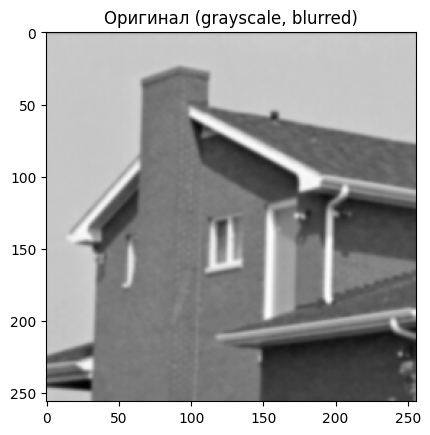

Длина WHT-хэша: 256 (блоков 16×16)
Длина Кравчук-хэша: 64 (блоков 32×32)
Общая длина: 320
Первые 32 бита: [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]

Запуск 1000 итераций наложения спекл-шума (sigma=1.0)...
  Выполнено 100 итераций
  Выполнено 200 итераций
  Выполнено 300 итераций
  Выполнено 400 итераций
  Выполнено 500 итераций
  Выполнено 600 итераций
  Выполнено 700 итераций
  Выполнено 800 итераций
  Выполнено 900 итераций
  Выполнено 1000 итераций

Тестирование завершено за 13.81 сек.

РЕЗУЛЬТАТЫ ПОСЛЕ 1000 ИТЕРАЦИЙ

WHT-хэш (длина 256):
  Среднее число несовпадающих бит: 44.92
  Средний NHD: 0.1755

Кравчук-хэш (длина 64):
  Среднее число несовпадающих бит: 3.27
  Средний NHD: 0.0511

Общий хэш (длина 320):
  Среднее число несовпадающих бит: 48.18
  Средний NHD: 0.1506


In [20]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy.linalg import hadamard
import time
import math

#  Вспомогательные функции

def preprocess(img_color, target_size=(256, 256)):
    gray = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)
    resized = cv2.resize(gray, target_size, interpolation=cv2.INTER_AREA)
    blurred = cv2.GaussianBlur(resized, (5, 5), 1.0)
    return blurred.astype(np.float32)

def split_blocks(img, block_size):
    h, w = img.shape
    assert h % block_size == 0 and w % block_size == 0
    blocks_h = h // block_size
    blocks_w = w // block_size
    blocks = img.reshape(blocks_h, block_size, blocks_w, block_size)
    blocks = blocks.swapaxes(1, 2).reshape(-1, block_size, block_size)
    return blocks

def get_zigzag_indices(n):
    indices = []
    for s in range(2*n-1):
        if s % 2 == 0:
            for i in range(min(s, n-1), max(-1, s-n), -1):
                j = s-i
                indices.append((i, j))
        else:
            for j in range(min(s, n-1), max(-1, s-n), -1):
                i = s-j
                indices.append((i, j))
    return indices


def wht2d(block, H):
    return H @ block @ H.T

def extract_wht_features(blocks, num_coeffs=16):
    n = blocks.shape[1]
    H = hadamard(n, dtype=np.float32) / np.sqrt(n)
    zigzag = get_zigzag_indices(n)
    n_blocks = blocks.shape[0]
    features = np.zeros((num_coeffs, n_blocks), dtype=np.float32)
    for i in range(n_blocks):
        coeff = wht2d(blocks[i], H)
        for k, (r, c) in enumerate(zigzag[:num_coeffs]):
            features[k, i] = coeff[r, c]
    return features

def krawtchouk_poly_recurrence(n, x, p, N):
    if n == 0:
        return 1.0
    if n == 1:
        return 1.0 - x / (p * (N - 1))

    K_prev = 1.0
    K_curr = 1.0 - x / (p * (N - 1))
    for m in range(1, n):
        A = (m + x * (1 - 2 * p) - p * (N - 1)) / (m + 1)
        B = -p * (1 - p) * ((N - 1) - m) / (m + 1)
        K_next = A * K_curr + B * K_prev
        K_prev, K_curr = K_curr, K_next
    return K_curr


def weighted_krawtchouk_matrix(N, p=0.5, order=3):
    w = np.array([math.comb(N - 1, x) * (p ** x) * ((1 - p) ** (N - 1 - x)) for x in range(N)])

    K = np.zeros((order + 1, N))
    for n in range(order + 1):
        for x in range(N):
            K[n, x] = krawtchouk_poly_recurrence(n, x, p, N)

    rho = np.array([abs(math.comb(N - 1, n) * (p / (1 - p)) ** n) for n in range(order + 1)])

    K_bar = np.zeros_like(K)
    for n in range(order + 1):
        for x in range(N):
            K_bar[n, x] = K[n, x] * np.sqrt(w[x] / rho[n])
    return K_bar


def build_krawtchouk_bases(block_size, p1=0.5, p2=0.5, order=3):
    Kx = weighted_krawtchouk_matrix(block_size, p1, order)
    Ky = weighted_krawtchouk_matrix(block_size, p2, order)

    bases = []
    for n in range(order + 1):
        for m in range(order + 1):
            bases.append(np.outer(Kx[n], Ky[m]))
    return bases


def extract_krawtchouk_features(blocks, bases):
    n_blocks = blocks.shape[0]
    n_mom = len(bases)
    features = np.zeros((n_mom, n_blocks), dtype=np.float32)
    for i in range(n_blocks):
        for j, basis in enumerate(bases):
            features[j, i] = np.sum(blocks[i] * basis)
    return features


def hash_from_features(features):
    global_mean = np.mean(features)
    col_means = np.mean(features, axis=0)
    return (col_means >= global_mean).astype(np.uint8)


# Добавление шума

def add_speckle_noise(img, sigma):
    img_float = img.astype(np.float32)
    noise = np.random.normal(0, sigma, img.shape).astype(np.float32)
    noisy = img_float + img_float * noise
    return np.clip(noisy, 0, 255).astype(np.uint8)
    
#  Основная часть

if __name__ == "__main__":
    # Параметры
    image_path = 'house.tiff'
    target_size = (256, 256)
    wht_block_size = 16
    kraw_block_size = 32
    num_coeffs = 128
    sigma = 1.0
    num_iterations = 1000
    order = 3
    p1 = p2 = 0.5

    original = cv2.imread(image_path)
    if original is None:
        raise FileNotFoundError(f"Не удалось загрузить {image_path}")

    print("Предобработка оригинального изображения...")
    proc_orig = preprocess(original, target_size)

    plt.imshow(proc_orig, cmap='gray')
    plt.title('Оригинал (grayscale, blurred)')
    plt.show()

    blocks_wht = split_blocks(proc_orig, wht_block_size)
    
    blocks_kraw = split_blocks(proc_orig, kraw_block_size)

    wht_features = extract_wht_features(blocks_wht, num_coeffs)
    hash_wht = hash_from_features(wht_features)

    kraw_bases = build_krawtchouk_bases(kraw_block_size, p1, p2, order)
    kraw_features = extract_krawtchouk_features(blocks_kraw, kraw_bases)
    hash_kraw = hash_from_features(kraw_features)

    full_hash = np.concatenate((hash_wht, hash_kraw))

    print(f"Длина WHT-хэша: {len(hash_wht)} (блоков {wht_block_size}×{wht_block_size})")
    print(f"Длина Кравчук-хэша: {len(hash_kraw)} (блоков {kraw_block_size}×{kraw_block_size})")
    print(f"Общая длина: {len(full_hash)}")

     # Тест на устойчивость к шуму
    total_wht_diff = 0
    total_wht_nhd = 0.0
    total_kraw_diff = 0
    total_kraw_nhd = 0.0
    total_full_diff = 0
    total_full_nhd = 0.0

    print(f"\nЗапуск {num_iterations} итераций наложения спекл-шума (sigma={sigma})...")
    start = time.perf_counter()

    for i in range(num_iterations):
        noisy_color = add_speckle_noise(original, sigma)

        proc_noisy = preprocess(noisy_color, target_size)

        blocks_wht_noisy = split_blocks(proc_noisy, wht_block_size)
        blocks_kraw_noisy = split_blocks(proc_noisy, kraw_block_size)

        # Хэши для зашумлённого
        wht_n = extract_wht_features(blocks_wht_noisy, num_coeffs)
        hash_wht_n = hash_from_features(wht_n)

        kraw_n = extract_krawtchouk_features(blocks_kraw_noisy, kraw_bases)
        hash_kraw_n = hash_from_features(kraw_n)

        full_n = np.concatenate((hash_wht_n, hash_kraw_n))

        # Сравнение
        total_wht_diff += np.sum(hash_wht != hash_wht_n)
        total_wht_nhd += np.sum(hash_wht != hash_wht_n) / len(hash_wht)

        total_kraw_diff += np.sum(hash_kraw != hash_kraw_n)
        total_kraw_nhd += np.sum(hash_kraw != hash_kraw_n) / len(hash_kraw)

        total_full_diff += np.sum(full_hash != full_n)
        total_full_nhd += np.sum(full_hash != full_n) / len(full_hash)

        if (i + 1) % 100 == 0:
            print(f"  Выполнено {i + 1} итераций")

    elapsed = time.perf_counter() - start
    print(f"\nТест завершен за {elapsed:.2f} сек.\n")

    # 4. Итоговые результаты
    print("=" * 60)
    print(f"РЕЗУЛЬТАТЫ ПОСЛЕ {num_iterations} ИТЕРАЦИЙ")
    print("=" * 60)

    avg_wht_diff = total_wht_diff / num_iterations
    avg_wht_nhd = total_wht_nhd / num_iterations
    print(f"\nWHT-хэш (длина {len(hash_wht)}):")
    print(f"  Среднее число несовпадающих бит: {avg_wht_diff:.2f}")
    print(f"  Средний NHD: {avg_wht_nhd:.4f}")

    avg_kraw_diff = total_kraw_diff / num_iterations
    avg_kraw_nhd = total_kraw_nhd / num_iterations
    print(f"\nКравчук-хэш (длина {len(hash_kraw)}):")
    print(f"  Среднее число несовпадающих бит: {avg_kraw_diff:.2f}")
    print(f"  Средний NHD: {avg_kraw_nhd:.4f}")

    avg_full_diff = total_full_diff / num_iterations
    avg_full_nhd = total_full_nhd / num_iterations
    print(f"\nОбщий хэш (длина {len(full_hash)}):")
    print(f"  Среднее число несовпадающих бит: {avg_full_diff:.2f}")
    print(f"  Средний NHD: {avg_full_nhd:.4f}")

Предобработка оригинального изображения...


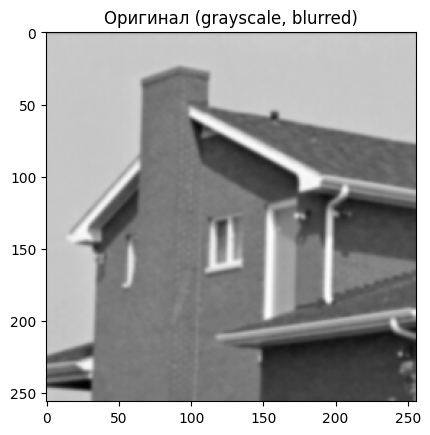

Длина WHT-хэша: 256 (блоков 16×16)
Длина Кравчук-хэша: 64 (блоков 32×32)
Общая длина: 320
Первые 32 бита: [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]

Применение аддитивного сдвига яркости с delta=150...


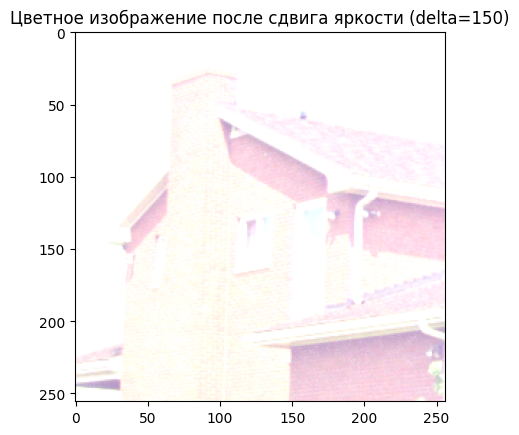

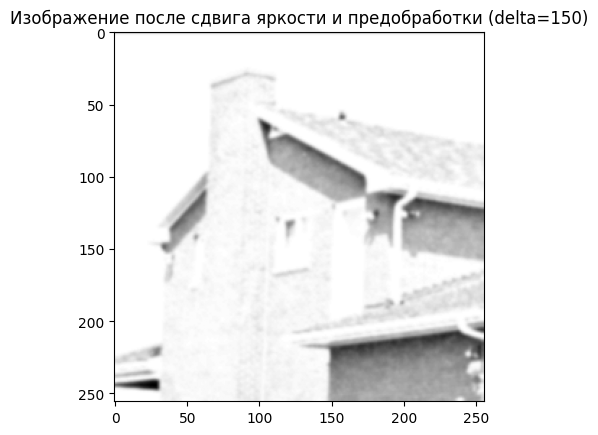


РЕЗУЛЬТАТЫ СРАВНЕНИЯ ПОСЛЕ АДДИТИВНОГО СДВИГА ЯРКОСТИ

WHT-хэш (длина 256):
  Несовпадающих бит: 104
  NHD: 0.4062

Кравчук-хэш (длина 64):
  Несовпадающих бит: 25
  NHD: 0.3906

Общий хэш (длина 320):
  Несовпадающих бит: 129
  NHD: 0.4031


In [160]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy.linalg import hadamard
import math

#  Вспомогательные функции

def preprocess(img_color, target_size=(256, 256)):
    gray = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)
    resized = cv2.resize(gray, target_size, interpolation=cv2.INTER_AREA)
    blurred = cv2.GaussianBlur(resized, (5, 5), 1.0)
    return blurred.astype(np.float32)


def split_blocks(img, block_size):
    h, w = img.shape
    assert h % block_size == 0 and w % block_size == 0
    blocks_h = h // block_size
    blocks_w = w // block_size
    blocks = img.reshape(blocks_h, block_size, blocks_w, block_size)
    blocks = blocks.swapaxes(1, 2).reshape(-1, block_size, block_size)
    return blocks


def get_zigzag_indices(n):
    indices = []
    for s in range(2*n-1):
        if s % 2 == 0:
            for i in range(min(s, n-1), max(-1, s-n), -1):
                j = s-i
                indices.append((i, j))
        else:
            for j in range(min(s, n-1), max(-1, s-n), -1):
                i = s-j
                indices.append((i, j))
    return indices

def wht2d(block, H):
    return H @ block @ H.T

def extract_wht_features(blocks, num_coeffs):
    n = blocks.shape[1]
    H = hadamard(n, dtype=np.float32) / np.sqrt(n)
    zigzag = get_zigzag_indices(n)
    n_blocks = blocks.shape[0]
    features = np.zeros((num_coeffs, n_blocks), dtype=np.float32)
    for i in range(n_blocks):
        coeff = wht2d(blocks[i], H)
        for k, (r, c) in enumerate(zigzag[:num_coeffs]):
            features[k, i] = coeff[r, c]
    return features

def krawtchouk_poly_recurrence(n, x, p, N):
    if n == 0:
        return 1.0
    if n == 1:
        return 1.0 - x / (p * (N - 1))

    K_prev = 1.0
    K_curr = 1.0 - x / (p * (N - 1))
    for m in range(1, n):
        A = (m + x * (1 - 2 * p) - p * (N - 1)) / (m + 1)
        B = -p * (1 - p) * ((N - 1) - m) / (m + 1)
        K_next = A * K_curr + B * K_prev
        K_prev, K_curr = K_curr, K_next
    return K_curr


def weighted_krawtchouk_matrix(N, p=0.5, order=3):
    w = np.array([math.comb(N - 1, x) * (p ** x) * ((1 - p) ** (N - 1 - x)) for x in range(N)])

    K = np.zeros((order + 1, N))
    for n in range(order + 1):
        for x in range(N):
            K[n, x] = krawtchouk_poly_recurrence(n, x, p, N)

    rho = np.array([abs(math.comb(N - 1, n) * (p / (1 - p)) ** n) for n in range(order + 1)])

    K_bar = np.zeros_like(K)
    for n in range(order + 1):
        for x in range(N):
            K_bar[n, x] = K[n, x] * np.sqrt(w[x] / rho[n])
    return K_bar


def build_krawtchouk_bases(block_size, p1=0.5, p2=0.5, order=3):
    Kx = weighted_krawtchouk_matrix(block_size, p1, order)
    Ky = weighted_krawtchouk_matrix(block_size, p2, order)

    bases = []
    for n in range(order + 1):
        for m in range(order + 1):
            bases.append(np.outer(Kx[n], Ky[m]))
    return bases


def extract_krawtchouk_features(blocks, bases):
    n_blocks = blocks.shape[0]
    n_mom = len(bases)
    features = np.zeros((n_mom, n_blocks), dtype=np.float32)
    for i in range(n_blocks):
        for j, basis in enumerate(bases):
            features[j, i] = np.sum(blocks[i] * basis)
    return features


def hash_from_features(features):
    global_mean = np.mean(features)
    col_means = np.mean(features, axis=0)
    return (col_means >= global_mean).astype(np.uint8)


# Добавление аддитивного сдвига яркости

def brightness_shift(img, delta=50):
    img_float = img.astype(np.float32) + delta
    return np.clip(img_float, 0, 255).astype(np.uint8)

# Основная часть
if __name__ == "__main__":
    image_path = 'house.tiff'
    target_size = (256, 256)
    wht_block_size = 16
    kraw_block_size = 32
    num_coeffs = 128
    order = 3
    p1 = p2 = 0.5
    brightness_delta = 150

    original = cv2.imread(image_path)
    if original is None:
        raise FileNotFoundError(f"Не удалось загрузить {image_path}")

    print("Предобработка оригинального изображения...")
    proc_orig = preprocess(original, target_size)

    plt.imshow(proc_orig, cmap='gray')
    plt.title('Оригинал (grayscale, blurred)')
    plt.show()

    blocks_wht = split_blocks(proc_orig, wht_block_size)
    blocks_kraw = split_blocks(proc_orig, kraw_block_size)

    wht_features = extract_wht_features(blocks_wht, num_coeffs)
    hash_wht = hash_from_features(wht_features)

    kraw_bases = build_krawtchouk_bases(kraw_block_size, p1, p2, order)
    kraw_features = extract_krawtchouk_features(blocks_kraw, kraw_bases)
    hash_kraw = hash_from_features(kraw_features)

    full_hash = np.concatenate((hash_wht, hash_kraw))

    print(f"Длина WHT-хэша: {len(hash_wht)} (блоков {wht_block_size}×{wht_block_size})")
    print(f"Длина Кравчук-хэша: {len(hash_kraw)} (блоков {kraw_block_size}×{kraw_block_size})")
    print(f"Общая длина: {len(full_hash)}")

    print(f"\nПрименение аддитивного сдвига яркости с delta={brightness_delta}...")
    bright_img = brightness_shift(original, brightness_delta)

    bright_img_rgb = cv2.cvtColor(bright_img, cv2.COLOR_BGR2RGB)
    plt.figure()
    plt.imshow(bright_img_rgb)
    plt.title(f"Цветное изображение после сдвига яркости (delta={brightness_delta})")
    plt.show()

    proc_bright = preprocess(bright_img, target_size)

    plt.figure()
    plt.imshow(proc_bright, cmap='gray')
    plt.title(f"Изображение после сдвига яркости и предобработки (delta={brightness_delta})")
    plt.show()

    blocks_wht_bright = split_blocks(proc_bright, wht_block_size)
    blocks_kraw_bright = split_blocks(proc_bright, kraw_block_size)

    # Хэши для искажённого
    wht_features_bright = extract_wht_features(blocks_wht_bright, num_coeffs)
    hash_wht_bright = hash_from_features(wht_features_bright)

    kraw_features_bright = extract_krawtchouk_features(blocks_kraw_bright, kraw_bases)
    hash_kraw_bright = hash_from_features(kraw_features_bright)

    full_hash_bright = np.concatenate((hash_wht_bright, hash_kraw_bright))

    # Сравнение
    print("\n" + "=" * 60)
    print("РЕЗУЛЬТАТЫ СРАВНЕНИЯ ПОСЛЕ АДДИТИВНОГО СДВИГА ЯРКОСТИ")
    print("=" * 60)

    wht_diff = np.sum(hash_wht != hash_wht_bright)
    wht_nhd = wht_diff / len(hash_wht)

    kraw_diff = np.sum(hash_kraw != hash_kraw_bright)
    kraw_nhd = kraw_diff / len(hash_kraw)

    full_diff = np.sum(full_hash != full_hash_bright)
    full_nhd = full_diff / len(full_hash)

    print(f"\nWHT-хэш (длина {len(hash_wht)}):")
    print(f"  Несовпадающих бит: {wht_diff}")
    print(f"  NHD: {wht_nhd:.4f}")

    print(f"\nКравчук-хэш (длина {len(hash_kraw)}):")
    print(f"  Несовпадающих бит: {kraw_diff}")
    print(f"  NHD: {kraw_nhd:.4f}")

    print(f"\nОбщий хэш (длина {len(full_hash)}):")
    print(f"  Несовпадающих бит: {full_diff}")
    print(f"  NHD: {full_nhd:.4f}")

Предобработка оригинального изображения...


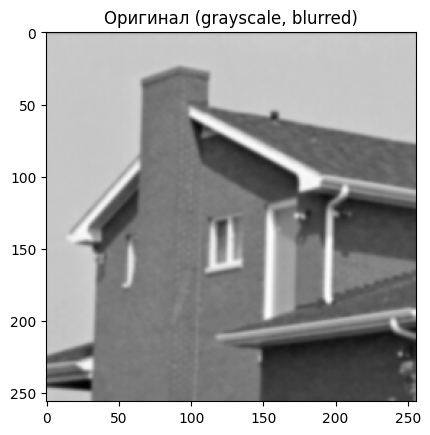

Длина WHT-хэша: 256 (блоков 16×16)
Длина Кравчук-хэша: 64 (блоков 32×32)
Общая длина: 320
Первые 32 бита: [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]

Применение обрезания: сторона='right', pixels=10...


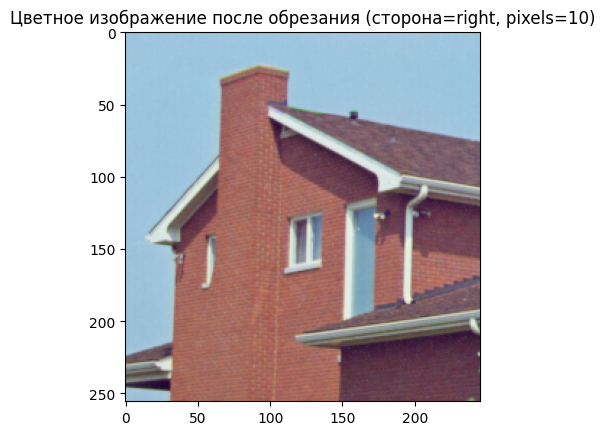

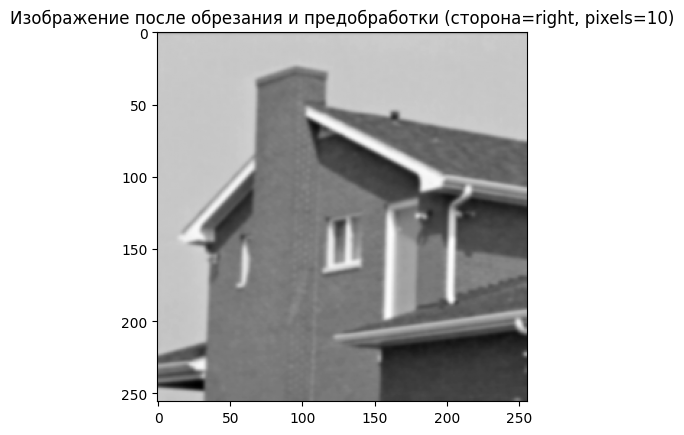


РЕЗУЛЬТАТЫ СРАВНЕНИЯ ПОСЛЕ ОБРЕЗАНИЯ

WHT-хэш (длина 256):
  Несовпадающих бит: 22
  NHD: 0.0859

Кравчук-хэш (длина 64):
  Несовпадающих бит: 6
  NHD: 0.0938

Общий хэш (длина 320):
  Несовпадающих бит: 28
  NHD: 0.0875


In [134]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy.linalg import hadamard
import math

#  Вспомогательные функции

def preprocess(img_color, target_size=(256, 256)):
    gray = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)
    resized = cv2.resize(gray, target_size, interpolation=cv2.INTER_AREA)
    blurred = cv2.GaussianBlur(resized, (5, 5), 1.0)
    return blurred.astype(np.float32)

def split_blocks(img, block_size):
    h, w = img.shape
    assert h % block_size == 0 and w % block_size == 0
    blocks_h = h // block_size
    blocks_w = w // block_size
    blocks = img.reshape(blocks_h, block_size, blocks_w, block_size)
    blocks = blocks.swapaxes(1, 2).reshape(-1, block_size, block_size)
    return blocks

def get_zigzag_indices(n):
    indices = []
    for s in range(2*n-1):
        if s % 2 == 0:
            for i in range(min(s, n-1), max(-1, s-n), -1):
                j = s-i
                indices.append((i, j))
        else:
            for j in range(min(s, n - 1), max(-1, s-n), -1):
                i = s-j
                indices.append((i, j))
    return indices

def wht2d(block, H):
    return H @ block @ H.T

def extract_wht_features(blocks, num_coeffs):
    n = blocks.shape[1]
    H = hadamard(n, dtype=np.float32) / np.sqrt(n)
    zigzag = get_zigzag_indices(n)
    n_blocks = blocks.shape[0]
    features = np.zeros((num_coeffs, n_blocks), dtype=np.float32)
    for i in range(n_blocks):
        coeff = wht2d(blocks[i], H)
        for k, (r, c) in enumerate(zigzag[:num_coeffs]):
            features[k, i] = coeff[r, c]
    return features

def krawtchouk_poly_recurrence(n, x, p, N):
    if n == 0:
        return 1.0
    if n == 1:
        return 1.0 - x / (p * (N - 1))

    K_prev = 1.0
    K_curr = 1.0 - x / (p * (N - 1))
    for m in range(1, n):
        A = (m + x * (1 - 2 * p) - p * (N - 1)) / (m + 1)
        B = -p * (1 - p) * ((N - 1) - m) / (m + 1)
        K_next = A * K_curr + B * K_prev
        K_prev, K_curr = K_curr, K_next
    return K_curr

def weighted_krawtchouk_matrix(N, p=0.5, order=3):
    w = np.array([math.comb(N - 1, x) * (p ** x) * ((1 - p) ** (N - 1 - x)) for x in range(N)])

    K = np.zeros((order + 1, N))
    for n in range(order + 1):
        for x in range(N):
            K[n, x] = krawtchouk_poly_recurrence(n, x, p, N)

    rho = np.array([abs(math.comb(N - 1, n) * (p / (1 - p)) ** n) for n in range(order + 1)])

    K_bar = np.zeros_like(K)
    for n in range(order + 1):
        for x in range(N):
            K_bar[n, x] = K[n, x] * np.sqrt(w[x] / rho[n])
    return K_bar


def build_krawtchouk_bases(block_size, p1=0.5, p2=0.5, order=3):
    Kx = weighted_krawtchouk_matrix(block_size, p1, order)
    Ky = weighted_krawtchouk_matrix(block_size, p2, order)

    bases = []
    for n in range(order + 1):
        for m in range(order + 1):
            bases.append(np.outer(Kx[n], Ky[m]))
    return bases


def extract_krawtchouk_features(blocks, bases):
    n_blocks = blocks.shape[0]
    n_mom = len(bases)
    features = np.zeros((n_mom, n_blocks), dtype=np.float32)
    for i in range(n_blocks):
        for j, basis in enumerate(bases):
            features[j, i] = np.sum(blocks[i] * basis)
    return features

def hash_from_features(features):
    global_mean = np.mean(features)
    col_means = np.mean(features, axis=0)
    return (col_means >= global_mean).astype(np.uint8)

# Добавление обрезки
def crop_image(img, side, pixels):
    h, w = img.shape[:2]
    if side == 'left':
        return img[:, pixels:w, :]
    elif side == 'right':
        return img[:, :w-pixels, :]
    elif side == 'top':
        return img[pixels:h, :, :]
    elif side == 'bottom':
        return img[:h-pixels, :, :]
    else:
        raise ValueError("side must be 'left', 'right', 'top' or 'bottom'")

#  Основная часть
if __name__ == "__main__":
    image_path = 'house.tiff'
    target_size = (256, 256)
    wht_block_size = 16
    kraw_block_size = 32
    num_coeffs = 128
    order = 3
    p1 = p2 = 0.5
    crop_side = 'right'
    crop_pixels = 10

    original = cv2.imread(image_path)
    if original is None:
        raise FileNotFoundError(f"Не удалось загрузить {image_path}")

    print("Предобработка оригинального изображения...")
    proc_orig = preprocess(original, target_size)

    plt.imshow(proc_orig, cmap='gray')
    plt.title('Оригинал (grayscale, blurred)')
    plt.show()

    blocks_wht = split_blocks(proc_orig, wht_block_size)
    blocks_kraw = split_blocks(proc_orig, kraw_block_size)

    wht_features = extract_wht_features(blocks_wht, num_coeffs)
    hash_wht = hash_from_features(wht_features)

    kraw_bases = build_krawtchouk_bases(kraw_block_size, p1, p2, order)
    kraw_features = extract_krawtchouk_features(blocks_kraw, kraw_bases)
    hash_kraw = hash_from_features(kraw_features)

    full_hash = np.concatenate((hash_wht, hash_kraw))

    print(f"Длина WHT-хэша: {len(hash_wht)} (блоков {wht_block_size}×{wht_block_size})")
    print(f"Длина Кравчук-хэша: {len(hash_kraw)} (блоков {kraw_block_size}×{kraw_block_size})")
    print(f"Общая длина: {len(full_hash)}")

    print(f"\nПрименение обрезания: сторона='{crop_side}', pixels={crop_pixels}...")
    cropped_color = crop_image(original, crop_side, crop_pixels)

    cropped_color_rgb = cv2.cvtColor(cropped_color, cv2.COLOR_BGR2RGB)
    plt.figure()
    plt.imshow(cropped_color_rgb)
    plt.title(f"Цветное изображение после обрезания (сторона={crop_side}, pixels={crop_pixels})")
    plt.show()

    proc_cropped = preprocess(cropped_color, target_size)

    plt.figure()
    plt.imshow(proc_cropped, cmap='gray')
    plt.title(f"Изображение после обрезания и предобработки (сторона={crop_side}, pixels={crop_pixels})")
    plt.show()

    # 4. Хэши для искажённого
    blocks_wht_crop = split_blocks(proc_cropped, wht_block_size)
    blocks_kraw_crop = split_blocks(proc_cropped, kraw_block_size)

    wht_features_crop = extract_wht_features(blocks_wht_crop, num_coeffs)
    hash_wht_crop = hash_from_features(wht_features_crop)

    kraw_features_crop = extract_krawtchouk_features(blocks_kraw_crop, kraw_bases)
    hash_kraw_crop = hash_from_features(kraw_features_crop)

    full_hash_crop = np.concatenate((hash_wht_crop, hash_kraw_crop))

    # 5. Сравнение хэшей
    print("\n" + "=" * 60)
    print("РЕЗУЛЬТАТЫ СРАВНЕНИЯ ПОСЛЕ ОБРЕЗАНИЯ")
    print("=" * 60)

    wht_diff = np.sum(hash_wht != hash_wht_crop)
    wht_nhd = wht_diff / len(hash_wht)

    kraw_diff = np.sum(hash_kraw != hash_kraw_crop)
    kraw_nhd = kraw_diff / len(hash_kraw)

    full_diff = np.sum(full_hash != full_hash_crop)
    full_nhd = full_diff / len(full_hash)

    print(f"\nWHT-хэш (длина {len(hash_wht)}):")
    print(f"  Несовпадающих бит: {wht_diff}")
    print(f"  NHD: {wht_nhd:.4f}")

    print(f"\nКравчук-хэш (длина {len(hash_kraw)}):")
    print(f"  Несовпадающих бит: {kraw_diff}")
    print(f"  NHD: {kraw_nhd:.4f}")

    print(f"\nОбщий хэш (длина {len(full_hash)}):")
    print(f"  Несовпадающих бит: {full_diff}")
    print(f"  NHD: {full_nhd:.4f}")